In [1]:
import calendar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_parquet("../data/incidents.parquet")

df["day_of_week"] = df["date"].dt.day_name()
df["day_of_week_num"] = df["date"].dt.dayofweek   # 0 = Monday
df["month_num"] = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M")

COMPLETE_YEARS = [2014, 2015, 2016, 2017]
df_complete = df[df["year"].isin(COMPLETE_YEARS)].copy()

## Annual trend (2014–2018)

As identified in EDA, 2013 contains only 278 incidents, while 2018 covers January through March only. Both years are shown for completeness but annotated as partial.

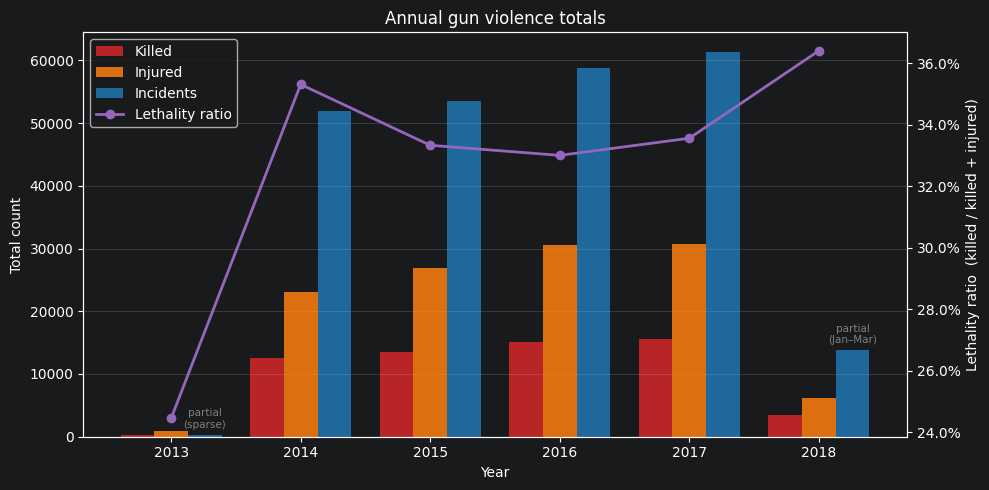

In [2]:
annual = (
    df.groupby("year")
    .agg(n_killed=("n_killed", "sum"), n_injured=("n_injured", "sum"), n_incidents=("n_killed", "count"))
    .reset_index()
)
annual["lethality"] = annual["n_killed"] / (annual["n_killed"] + annual["n_injured"])

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

width = 0.26
x = annual["year"].values

ax1.bar(x - width, annual["n_killed"],    width, label="Killed",    color="#d62728", alpha=0.85)
ax1.bar(x,         annual["n_injured"],   width, label="Injured",   color="#ff7f0e", alpha=0.85)
ax1.bar(x + width, annual["n_incidents"], width, label="Incidents", color="#1f77b4", alpha=0.85)
ax2.plot(x, annual["lethality"], color="#9467bd", marker="o", lw=2, label="Lethality ratio")

for yr, label in [(2013, "partial\n(sparse)"), (2018, "partial\n(Jan–Mar)")]:
    row = annual[annual["year"] == yr]
    if row.empty:
        continue
    ax1.text(yr + width, row["n_incidents"].values[0] + 800, label,
             ha="center", va="bottom", fontsize=7.5, color="grey")

ax1.set_xlabel("Year")
ax1.set_ylabel("Total count")
ax2.set_ylabel("Lethality ratio  (killed / killed + injured)")
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.set_title("Annual gun violence totals")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

We can see an increasing trend in both number of killed, injured and incidents over time. We observe no such trend for lethality ratio.

## Monthly time series (2014–2018)

Let's inspect a monthly time series from January 2014 to March 2018.

In [3]:
monthly = (
    df[df["year"] >= 2014]
    .groupby("year_month")
    .agg(n_killed=("n_killed", "sum"), n_injured=("n_injured", "sum"), n_incidents=("n_killed", "count"))
    .reset_index()
)
monthly["date"] = monthly["year_month"].dt.to_timestamp()
monthly["lethality"] = monthly["n_killed"] / (monthly["n_killed"] + monthly["n_injured"])

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    vertical_spacing=0.08,
    subplot_titles=("Monthly totals", "Lethality ratio  (killed / killed + injured)"),
)

fig.add_trace(go.Scatter(x=monthly["date"], y=monthly["n_killed"],    name="Killed",    line=dict(color="#d62728")),             row=1, col=1)
fig.add_trace(go.Scatter(x=monthly["date"], y=monthly["n_injured"],   name="Injured",   line=dict(color="#ff7f0e")),             row=1, col=1)
fig.add_trace(go.Scatter(x=monthly["date"], y=monthly["n_incidents"], name="Incidents", line=dict(color="#1f77b4", dash="dot")), row=1, col=1)
fig.add_trace(go.Scatter(x=monthly["date"], y=monthly["lethality"],   name="Lethality", line=dict(color="#9467bd")),             row=2, col=1)

fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Ratio", tickformat=".0%", row=2, col=1)
fig.update_layout(
    title="Monthly gun violence trends (2014–2018)",
    hovermode="x unified",
    height=520,
)
fig.show()

We can identify some seasonality in our data. Let's take a closer look at monthly seasonality.

## Monthly seasonality

Only four complete years (2014–2017) were used to isolate the within-year pattern.

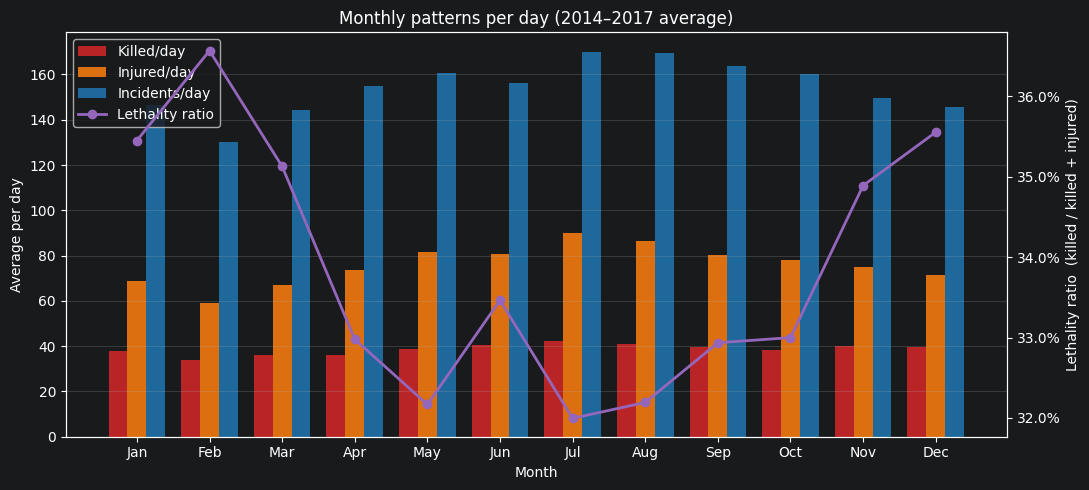

In [4]:
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Average days per month across the four complete years (February: 28.25 due to 2016 leap year)
avg_days_per_month = {
    m: np.mean([calendar.monthrange(y, m)[1] for y in COMPLETE_YEARS])
    for m in range(1, 13)
}

monthly_season = (
    df_complete.groupby(["year", "month_num"])
    .agg(n_killed=("n_killed", "sum"), n_injured=("n_injured", "sum"), n_incidents=("n_killed", "count"))
    .reset_index()
    .groupby("month_num")[["n_killed", "n_injured", "n_incidents"]]
    .mean()
    .reset_index()
)
for col in ["n_killed", "n_injured", "n_incidents"]:
    monthly_season[f"{col}_pd"] = monthly_season.apply(
        lambda r, c=col: r[c] / avg_days_per_month[int(r["month_num"])], axis=1
    )
monthly_season["lethality"] = monthly_season["n_killed"] / (monthly_season["n_killed"] + monthly_season["n_injured"])

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = monthly_season["month_num"].values
width = 0.26

ax1.bar(x - width, monthly_season["n_killed_pd"],    width, label="Killed/day",    color="#d62728", alpha=0.85)
ax1.bar(x,         monthly_season["n_injured_pd"],   width, label="Injured/day",   color="#ff7f0e", alpha=0.85)
ax1.bar(x + width, monthly_season["n_incidents_pd"], width, label="Incidents/day", color="#1f77b4", alpha=0.85)
ax2.plot(x, monthly_season["lethality"], color="#9467bd", marker="o", lw=2, label="Lethality ratio")

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(MONTH_NAMES)
ax1.set_xlabel("Month")
ax1.set_ylabel("Average per day")
ax2.set_ylabel("Lethality ratio  (killed / killed + injured)")
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.set_title("Monthly patterns per day (2014–2017 average)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Number of injured, killed and incidents averaged per day peaks in July. However, lethality ratio then is the lowest, at 32%, while peaking in February, which has the lowest number of injured, killed and incidents, at 36%.

## Day-of-week patterns

To avoid bias from unequal weekday counts across years, we divide each weekday's total by the number of times that weekday appears in the 2014–2017 date range, giving an average per calendar day.

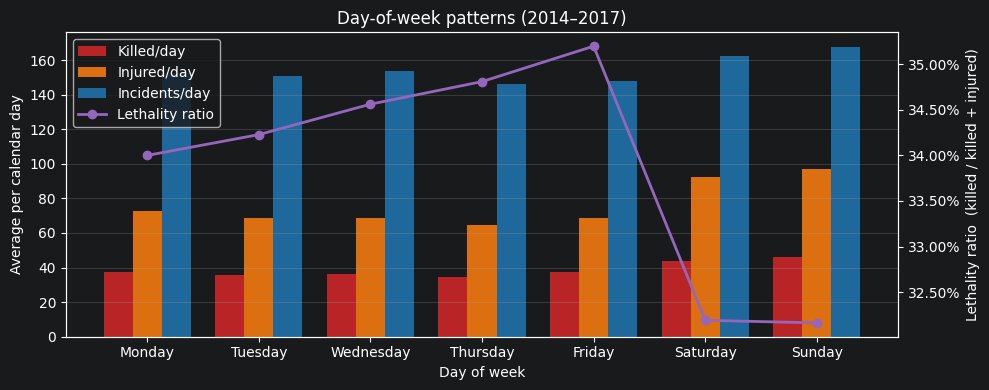

In [5]:
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

date_range_complete = pd.date_range("2014-01-01", "2017-12-31", freq="D")
weekday_days_in_range = (
    pd.Series(date_range_complete.day_name())
    .value_counts()
    .rename("n_days")
)

dow_totals = (
    df_complete.groupby("day_of_week")
    .agg(n_killed=("n_killed", "sum"), n_injured=("n_injured", "sum"), n_incidents=("n_killed", "count"))
    .join(weekday_days_in_range)
)
for col in ["n_killed", "n_injured", "n_incidents"]:
    dow_totals[f"avg_{col}"] = dow_totals[col] / dow_totals["n_days"]
dow_totals["lethality"] = dow_totals["n_killed"] / (dow_totals["n_killed"] + dow_totals["n_injured"])
dow_totals = dow_totals.reindex(DOW_ORDER)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

x = np.arange(len(DOW_ORDER))
width = 0.26

ax1.bar(x - width, dow_totals["avg_n_killed"],    width, label="Killed/day",    color="#d62728", alpha=0.85)
ax1.bar(x,         dow_totals["avg_n_injured"],   width, label="Injured/day",   color="#ff7f0e", alpha=0.85)
ax1.bar(x + width, dow_totals["avg_n_incidents"], width, label="Incidents/day", color="#1f77b4", alpha=0.85)
ax2.plot(x, dow_totals["lethality"], color="#9467bd", marker="o", lw=2, label="Lethality ratio")

ax1.set_xticks(x)
ax1.set_xticklabels(DOW_ORDER)
ax1.set_xlabel("Day of week")
ax1.set_ylabel("Average per calendar day")
ax2.set_ylabel("Lethality ratio  (killed / killed + injured)")
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.set_title("Day-of-week patterns (2014–2017)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Weekends are days were the number of killed, injured and incidents is visibly the highest, but lethality ration is the lowest. This suggests social/alcohol-fueled violence rather than targeted killings.

## Daily seasonality

Let's inspect how the daily count of people killed and injured varies over time and try to identify specific days in which peaks occur.

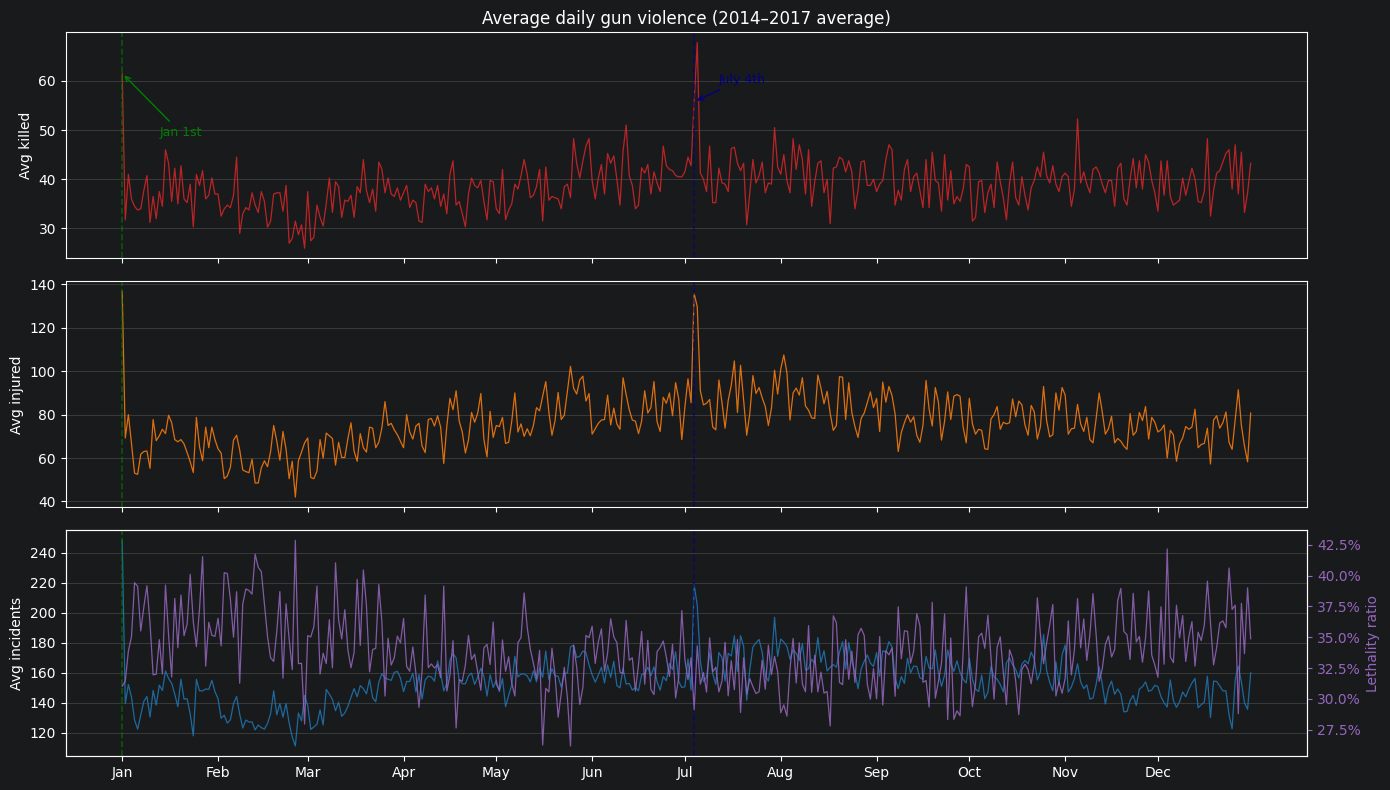

In [6]:
df_complete["month_day"] = df_complete["date"].dt.strftime("%m-%d")

daily_avg = (
    df_complete.groupby(["year", "month_day"])
    .agg(n_killed=("n_killed", "sum"), n_injured=("n_injured", "sum"), n_incidents=("n_killed", "count"))
    .reset_index()
    .groupby("month_day")[["n_killed", "n_injured", "n_incidents"]]
    .mean()
    .reset_index()
)
daily_avg["sort_date"] = pd.to_datetime("2016-" + daily_avg["month_day"], errors="coerce")
daily_avg = daily_avg.dropna(subset=["sort_date"]).sort_values("sort_date").reset_index(drop=True)
daily_avg["lethality"] = daily_avg["n_killed"] / (daily_avg["n_killed"] + daily_avg["n_injured"])

july4_idx = daily_avg.index[daily_avg["month_day"] == "07-04"][0]
jan1_idx  = daily_avg.index[daily_avg["month_day"] == "01-01"][0]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
ax_twin = axes[2].twinx()

for ax, col, color, ylabel in [
    (axes[0], "n_killed",    "#d62728", "Avg killed"),
    (axes[1], "n_injured",   "#ff7f0e", "Avg injured"),
    (axes[2], "n_incidents", "#1f77b4", "Avg incidents"),
]:
    ax.plot(daily_avg.index, daily_avg[col], color=color, lw=0.9, alpha=0.85)
    ax.axvline(july4_idx, color="navy",  lw=1.2, linestyle="--", alpha=0.6)
    ax.axvline(jan1_idx,  color="green", lw=1.2, linestyle="--", alpha=0.6)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

ax_twin.plot(daily_avg.index, daily_avg["lethality"], color="#9467bd", lw=0.9, alpha=0.85)
ax_twin.set_ylabel("Lethality ratio", color="#9467bd")
ax_twin.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax_twin.tick_params(axis="y", colors="#9467bd")

# Annotate on top subplot only
axes[0].annotate("July 4th", xy=(july4_idx, daily_avg.loc[july4_idx, "n_killed"]),
                 xytext=(july4_idx + 8, daily_avg["n_killed"].max() * 0.88),
                 arrowprops=dict(arrowstyle="->", color="navy"), color="navy", fontsize=9)
axes[0].annotate("Jan 1st",  xy=(jan1_idx, daily_avg.loc[jan1_idx, "n_killed"]),
                 xytext=(jan1_idx + 12, daily_avg["n_killed"].max() * 0.72),
                 arrowprops=dict(arrowstyle="->", color="green"), color="green", fontsize=9)

month_starts = daily_avg[daily_avg["month_day"].str.endswith("-01")].index
axes[2].set_xticks(month_starts)
axes[2].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
axes[0].set_title("Average daily gun violence (2014–2017 average)")
plt.tight_layout()
plt.show()

There are two extremely high values for numbers of killed, injured and incidents. One seems to be New Year's Eve, the other Independence Day. We can also observe that lethality ratio does not seem as high for these two dates - again suggesting social/alcohol-fueled violence rather than targeted killings.